# FASE 2: Data Preparation
This notebook handles the preparation of data for modeling, including encoding, scaling, and splitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append(os.path.abspath('../src'))
from data_preprocessing import load_data, prepare_data_pipeline

# Set visual style
sns.set(style="whitegrid")

## 1. Load Data
Loading datasets and merging them for preparation.

In [2]:
# Load datasets
path_data = '../data/'
consultas = pd.read_csv(os.path.join(path_data, 'consultas.csv'))
pacientes = pd.read_csv(os.path.join(path_data, 'pacientes.csv'))

# Merge datasets to create a base for modeling
df = consultas.merge(pacientes, on='id_paciente', how='left')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1437, 15)


,id_consulta,id_paciente,fecha,id_medico,especialidad,diagnostico_principal,diagnostico_secundario,costo,nombre,rut,fecha_nacimiento,genero,prevision,comuna,telefono
0,1.0,223.0,01/01/2023,43.0,PEDIATRÍA,Fractura,Ninguno,315120.0,Sebastián Rodríguez González,8786338-3,03/07/1979,Masculino,fonasa c,Quilpué,5.697411e+10
1,2.0,174.0,2023-01-01,4.0,pediatría,Infección respiratoria,NaN,401661.0,Camila Martínez López,24935310-9,1970-10-13,Femenino,Isapre,Los Ángeles,5.697747e+10
2,3.0,191.0,02/01/2023,42.0,Oftalmología,Diabetes,Depresión,367092.0,Carlos Contreras Flores,7640249-5,1973-10-22,masculino,Fonasa D,Ovalle,5.692649e+10
3,4.0,140.0,2023-01-03,1.0,Oftalmología,NaN,Obesidad,219153.0,Constanza Silva Rodríguez,6874923-5,1964-09-24,Masculino,Isapre,Castro,5.693005e+10
4,5.0,297.0,NaN,34.0,NaN,Control preventivo,Ninguno,410456.0,NaN,NaN,01/09/1992,Femenino,FONASA C,Chillán,5.699288e+10


## 2. Define Features (X) and Target (y)

In [3]:
# Define features and target
# Note: In a real scenario, we'd select specific features. 
# Here we take columns likely to be inputs and 'especialidad' as target.
target = 'especialidad'
features = [col for col in df.columns if col not in [target, 'id_consulta', 'id_paciente', 'fecha_consulta']]

X = df[features]
y = df[target]

print(f"Features: {features}")
print(f"Target: {target}")

Features: ['fecha', 'id_medico', 'diagnostico_principal', 'diagnostico_secundario', 'costo', 'nombre', 'rut', 'fecha_nacimiento', 'genero', 'prevision', 'comuna', 'telefono']
Target: especialidad


## 3. Label Encoding and Scaling
Using LabelEncoder for categorical variables and StandardScaler for numeric features.

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode categorical features
X_encoded = X.copy()
for col in cat_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# Scale numeric features
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print("Data encoded and scaled.")

Data encoded and scaled.


C:\Users\juany\AppData\Local\Temp\ipykernel_19928\2640047446.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


## 4. Split Data
80/20 split with stratification.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(1149, 12), y=(1149,)
Test shapes: X=(288, 12), y=(288,)


## 5. Visualize Prepared Data

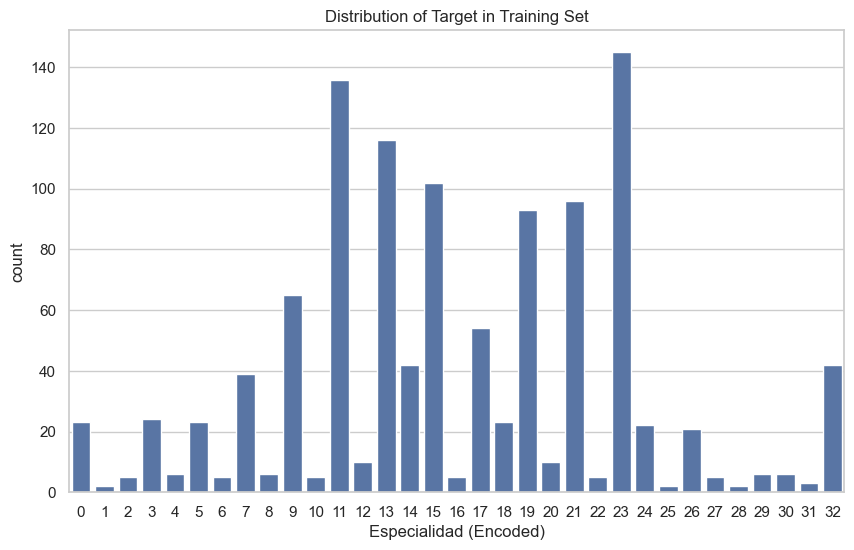

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title('Distribution of Target in Training Set')
plt.xlabel('Especialidad (Encoded)')
plt.show()

## 6. Save Preprocessed Data

In [7]:
output_path = '../data/processed/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Save as numpy arrays or csv
X_train.to_csv(os.path.join(output_path, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_path, 'X_test.csv'), index=False)
pd.DataFrame(y_train).to_csv(os.path.join(output_path, 'y_train.csv'), index=False)
pd.DataFrame(y_test).to_csv(os.path.join(output_path, 'y_test.csv'), index=False)

print(f"Files saved to {output_path}")

Files saved to ../data/processed/
